In [1]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

In [2]:
X, y = make_classification(n_classes=2, n_clusters_per_class=1, n_features=2, n_informative=1, n_redundant=0, n_samples=100,
                          random_state=43, hypercube=False, class_sep=50)

In [3]:
X.shape

(100, 2)

In [4]:
y.shape

(100,)

In [5]:
import matplotlib.pyplot as plt

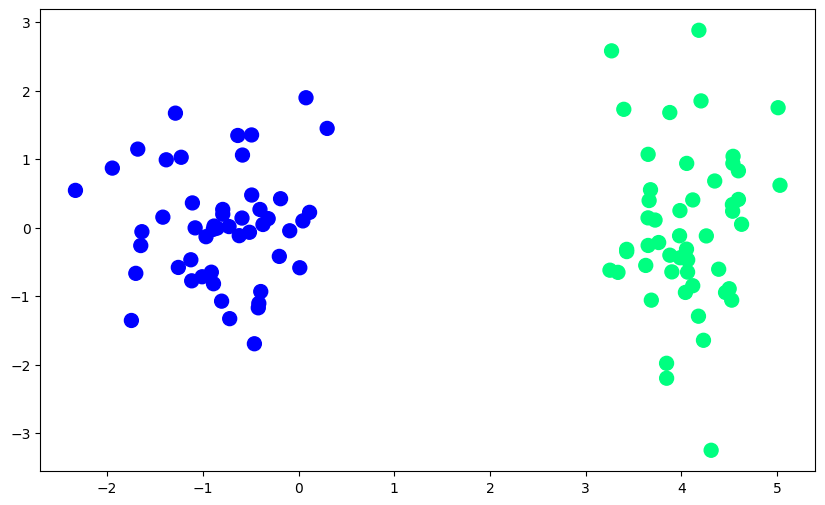

In [6]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0], X[:, 1],c=y, cmap="winter", s=100)
plt.show()

In [7]:
import numpy as np

In [8]:
def perceptron(X, y):

    X = np.insert(X, 0, 1, axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1

    for i in range(1000):
        j = np.random.randint(0,100)
        y_hat = step(np.dot(X[j], weights))    #step fun >> return 1 if x>0 else return 0
        weights = weights + lr*(y[j] - y_hat)*X[j]

    return weights[0], weights[1:]

In [9]:
def step(z):
    return 1 if z>0 else 0 

In [10]:
perceptron(X,y)

(-0.3999999999999999, array([ 1.23948526, -0.03762787]))

In [11]:
intercept_, coef_ = perceptron(X, y)

In [12]:
print(intercept_)
print(coef_)

-0.3999999999999999
[ 1.22071247 -0.0772759 ]


In [13]:
m = - coef_[0]/coef_[1]
b = - intercept_ / coef_[1]

In [14]:
print(m, b)

15.79680766055891 -5.176258307797187


In [15]:
x_input = np.linspace(-3, 3, 100)
y_input = m*x_input + b

(-3.0, 2.0)

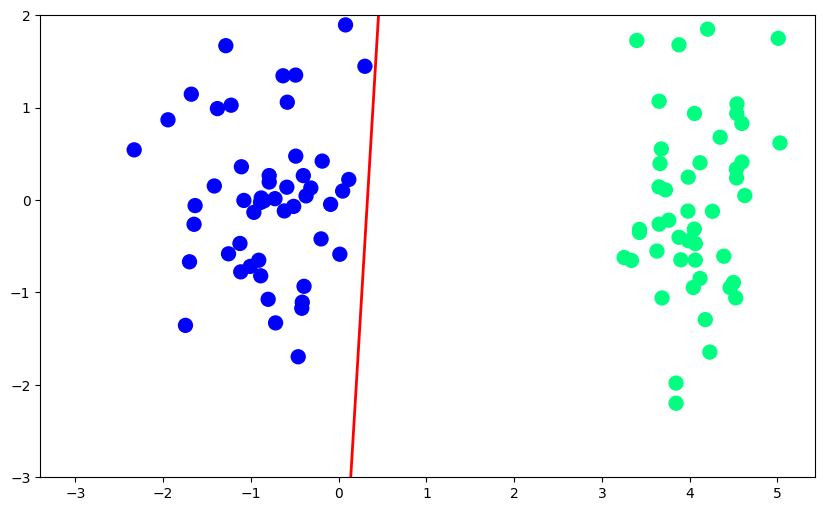

In [16]:
plt.figure(figsize=(10,6))
plt.plot(x_input, y_input, c="red", lw=2)
plt.scatter(X[:,0], X[:,1], c=y, cmap="winter", s =100)
plt.ylim(-3,2)

In [17]:
def perceptron1(X,y):
    
    m = []
    b = []
    
    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1
    
    for i in range(200):
        j = np.random.randint(0,100)
        y_hat = step(np.dot(X[j],weights))
        weights = weights + lr*(y[j]-y_hat)*X[j]
        
        m.append(-(weights[1]/weights[2]))
        b.append(-(weights[0]/weights[2]))
        
    return m,b

In [18]:
m, b = perceptron1(X, y)

In [19]:
%matplotlib inline
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation

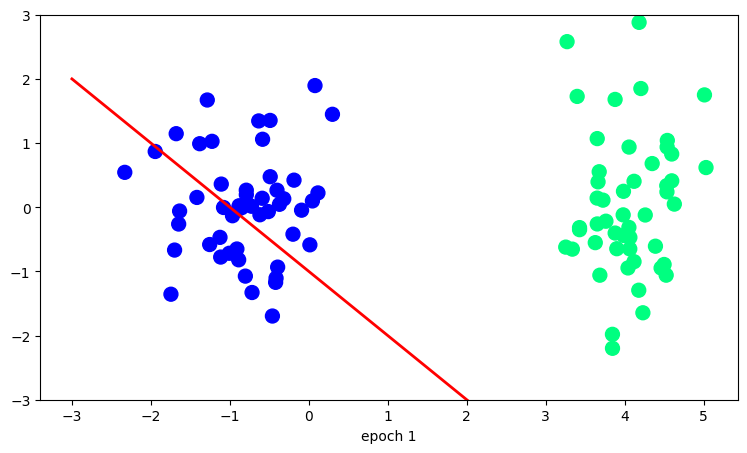

In [20]:
fig, ax = plt.subplots(figsize=(9,5))

x_i = np.arange(-3, 3, 0.1)
y_i = x_i*m[0] +b[0]
ax.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
line, = ax.plot(x_i, x_i*m[0] +b[0] , 'r-', linewidth=2)
plt.ylim(-3,3)
def update(i):
    label = 'epoch {0}'.format(i + 1)
    line.set_ydata(x_i*m[i] + b[i])
    ax.set_xlabel(label)
    # return line, ax

anim = FuncAnimation(fig, update, repeat=True, frames=200, interval=100)
f = r"perceptron trick plot.gif" 
writergif = animation.PillowWriter(fps=2) 
anim.save(f, writer=writergif)

#fig.suptitle('perceptron trick plot', fontsize=14)
#fig.save('perceptron_trick.mp4', writer=anim)

In [21]:
# Logistic regression using sklearn

In [22]:
from sklearn.linear_model import LogisticRegression

In [27]:
lor = LogisticRegression(penalty=None, solver="sag")

In [28]:
lor.fit(X, y)

C:\Users\kumar\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(penalty=None, solver='sag')

In [29]:
m = -lor.coef_[0][0]/lor.coef_[0][1]
b = -lor.intercept_/lor.coef_[0][1]

In [30]:
print(m, b)

8.116611013083524 [-10.63863465]


In [31]:
x_input1 = np.linspace(-3, 3, 100)
y_input1 = m*x_input1 + b

(-3.0, 2.0)

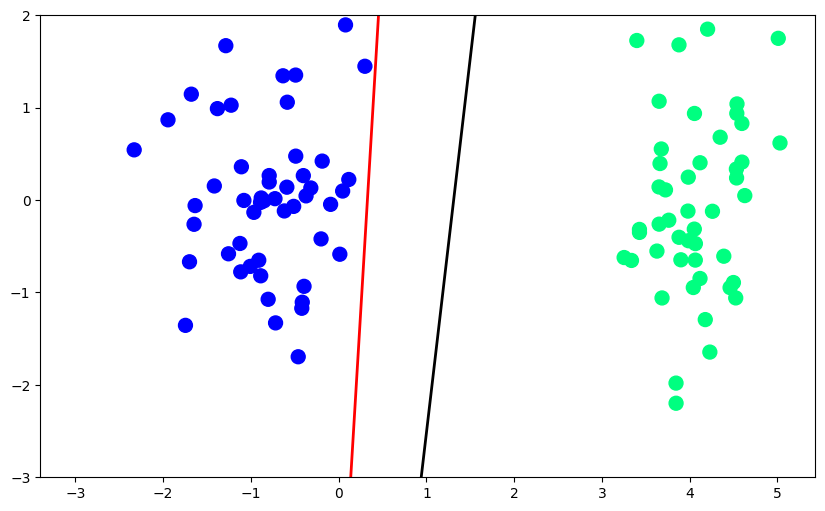

In [32]:
plt.figure(figsize=(10,6))
plt.plot(x_input, y_input, c="red", lw=2)
plt.plot(x_input1, y_input1, c="black", lw=2)
plt.scatter(X[:,0], X[:,1], c=y, cmap="winter", s =100)
plt.ylim(-3,2)

In [33]:
def perceptron2(X, y):

    X = np.insert(X, 0, 1, axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1

    for i in range(1000):
        j = np.random.randint(0,100)
        y_hat = sigmoid(np.dot(X[j], weights))    #step fun >> return 1 if x>0 else return 0
        weights = weights + lr*(y[j] - y_hat)*X[j]

    return weights[0], weights[1:]

In [34]:
def sigmoid(z):
    return 1 / (1+np.exp(-z))

In [35]:
intercept_, coef_ = perceptron2(X, y)

In [36]:
m = - coef_[0]/coef_[1]
b = - intercept_ / coef_[1]

In [37]:
x_input2 = np.linspace(-3, 3, 100)
y_input2 = m*x_input2 + b

(-3.0, 2.0)

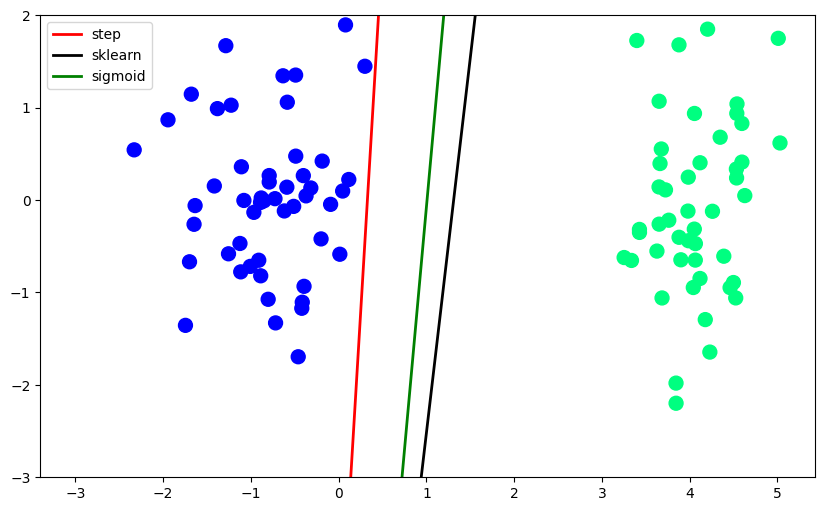

In [38]:
plt.figure(figsize=(10,6))
plt.plot(x_input, y_input, c="red", lw=2, label="step")
plt.plot(x_input1, y_input1, c="black", lw=2, label="sklearn")
plt.plot(x_input2, y_input2, c="green", lw=2, label="sigmoid")
plt.scatter(X[:,0], X[:,1], c=y, cmap="winter", s =100)
plt.legend()
plt.ylim(-3,2)

In [39]:
# Now using gradient discent

In [265]:
def gd(X, y):

    X = np.insert(X, 0, 1, axis=1)
    weights = np.ones(X.shape[1])

    lr = 0.5
    for i in range(1500):
        y_hat = sigmoid(np.dot(X, weights))
        weights = weights + lr * (np.dot((y-y_hat), X)/(X.shape[0]))
    
    return weights[1:], weights[0]
    

In [266]:
def sigmoid(z):
    return 1 / (1+np.exp(-z))

In [267]:
X1 = np.insert(X, 0, 1, axis=1)
np.ones(X1.shape[1])

array([1., 1., 1.])

In [268]:
coef_, intercept_ = gd(X, y)

In [269]:
print(coef_, intercept_)

[ 3.42800243 -0.34117342] -4.494850128479841


In [270]:
m = - coef_[0]/coef_[1]
b = - intercept_ / coef_[1]

In [271]:
x_input3 = np.linspace(-3, 3, 100)
y_input3 = m*x_input3 + b

(-3.0, 2.0)

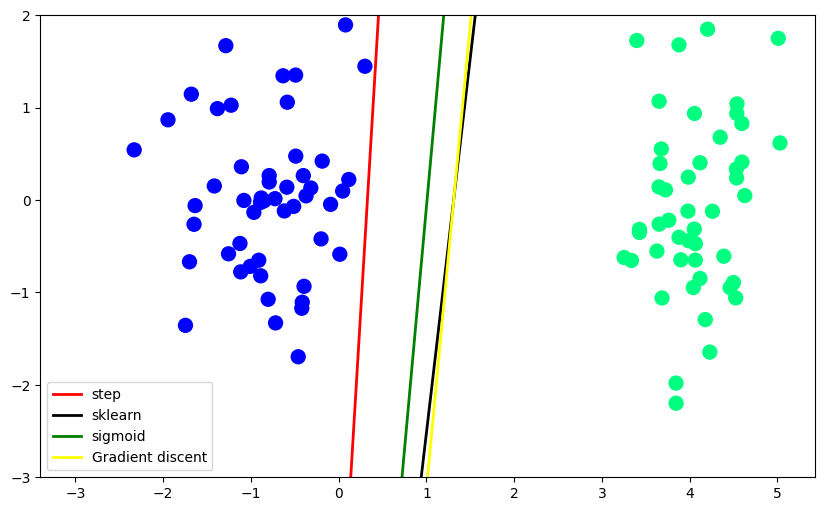

In [272]:
plt.figure(figsize=(10,6))
plt.plot(x_input, y_input, c="red", lw=2, label="step")
plt.plot(x_input1, y_input1, c="black", lw=2, label="sklearn")
plt.plot(x_input2, y_input2, c="green", lw=2, label="sigmoid")
plt.plot(x_input3, y_input3, c="yellow", lw=2, label="Gradient discent")
plt.scatter(X[:,0], X[:,1], c=y, cmap="winter", s =100)
plt.legend()
plt.ylim(-3,2)